<a href="https://colab.research.google.com/github/Abghani235/Abghani235/blob/main/S25_B9_ML_G44_E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### بـسـم الله الرحـمـن الرحـيـم

In [ ]:
from seaborn import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = load_dataset('tips')

In [ ]:
df.sample(10)

,total_bill,tip,sex,smoker,day,time,size
199,13.51,2.00,Male,Yes,Thur,Lunch,2
23,39.42,7.58,Male,No,Sat,Dinner,4
67,3.07,1.00,Female,Yes,Sat,Dinner,1
105,15.36,1.64,Male,Yes,Sat,Dinner,2
239,29.03,5.92,Male,No,Sat,Dinner,3
98,21.01,3.00,Male,Yes,Fri,Dinner,2
156,48.17,5.00,Male,No,Sun,Dinner,6
123,15.95,2.00,Male,No,Thur,Lunch,2
209,12.76,2.23,Female,Yes,Sat,Dinner,2
117,10.65,1.50,Female,No,Thur,Lunch,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [ ]:
df.describe(include='all')

,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


total_bill


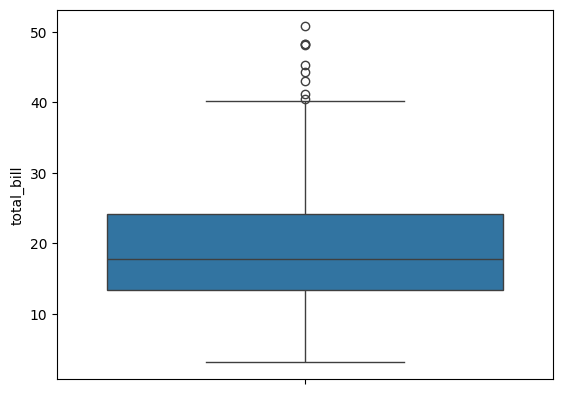

tip


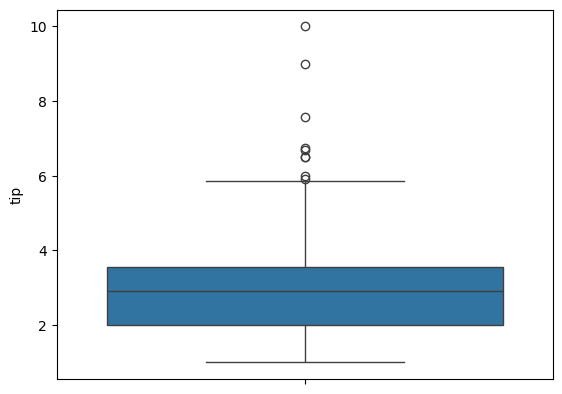

size


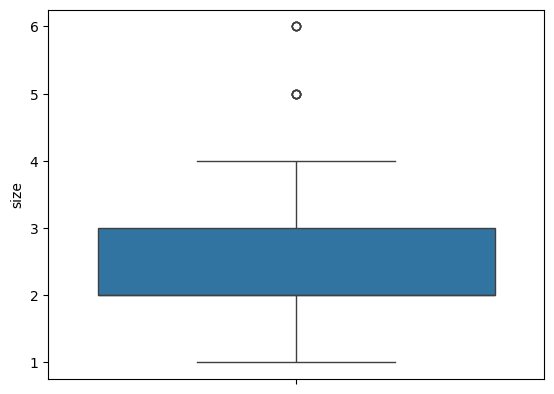

In [ ]:
for i in df.select_dtypes(include='number'):
    print(i)
    sns.boxplot(df[i])
    plt.show()

In [ ]:
def remove_outliers(df, col_name):
    q1 = df[col_name].quantile(0.25)
    q3 = df[col_name].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df_out = df.loc[(df[col_name] > lower_bound) & (df[col_name] < upper_bound)]
    return df_out

In [ ]:
df.isna().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
x=df.drop('tip',axis=1)
y=df['tip']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#ohe
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(drop='first')
ohe.fit(x_train[['sex','smoker','day','time']])
x_train_new=ohe.transform(x_train[['sex','smoker','day','time']]).toarray()
x_test_new=ohe.transform(x_test[['sex','smoker','day','time']]).toarray()

In [ ]:
x_train.head()

,total_bill,sex,smoker,day,time,size
228,13.28,Male,No,Sat,Dinner,2
208,24.27,Male,Yes,Sat,Dinner,2
96,27.28,Male,Yes,Fri,Dinner,2
167,31.71,Male,No,Sun,Dinner,4
84,15.98,Male,No,Thur,Lunch,2


In [ ]:
x_train.drop(['sex','smoker','day','time'],axis=1,inplace=True)
x_test.drop(['sex','smoker','day','time'],axis=1,inplace=True)
encoded_train=pd.DataFrame(x_train_new,columns=ohe.get_feature_names_out())
encoded_test=pd.DataFrame(x_test_new,columns=ohe.get_feature_names_out())
encoded_train.reset_index(drop=True,inplace=True)
encoded_test.reset_index(drop=True,inplace=True)
x_train.reset_index(drop=True,inplace=True)
x_test.reset_index(drop=True,inplace=True)
x_train=pd.concat([x_train,encoded_train],axis=1)
x_test=pd.concat([x_test,encoded_test],axis=1)

In [ ]:
x_train.head()

,total_bill,size,sex_Male,smoker_Yes,day_Sat,day_Sun,day_Thur,time_Lunch
0,-0.793062,-0.612141,0.731733,-0.790569,1.336306,-0.674703,-0.563531,-0.610933
1,0.463227,-0.612141,0.731733,1.264911,1.336306,-0.674703,-0.563531,-0.610933
2,0.807307,-0.612141,0.731733,1.264911,-0.748331,-0.674703,-0.563531,-0.610933
3,1.313709,1.519421,0.731733,-0.790569,-0.748331,1.482134,-0.563531,-0.610933
4,-0.484419,-0.612141,0.731733,-0.790569,-0.748331,-0.674703,1.774524,1.636840


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
sc.fit(x_train)
x_train=pd.DataFrame(sc.transform(x_train),columns=x_train.columns)
x_test=pd.DataFrame(sc.transform(x_test),columns=x_test.columns)

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error
y_pred=lr.predict(x_test)
mean_squared_error(y_test,y_pred)

0.7033566017436103

In [ ]:
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=0.08)
lasso.fit(x_train,y_train)

Lasso(alpha=0.08)

In [ ]:
from sklearn.metrics import mean_squared_error
y_pred=lasso.predict(x_test)
mean_squared_error(y_test,y_pred)

0.6193351771633283

In [ ]:
lr.coef_

array([ 0.82843209,  0.21907315,  0.01373425, -0.09358068, -0.08912114,
       -0.02354994, -0.07686771,  0.04224499])

In [ ]:
lasso.coef_

array([ 0.74591858,  0.19557381,  0.        , -0.00769151, -0.        ,
        0.        ,  0.        ,  0.        ])

###Decision Tree

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
df=load_iris()

In [ ]:
df.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
df

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [ ]:
x=df['data']

In [ ]:
y=df['target']

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
iris_df=pd.DataFrame(df['data'],columns=df['feature_names'])
iris_df['target']=df['target']

In [ ]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


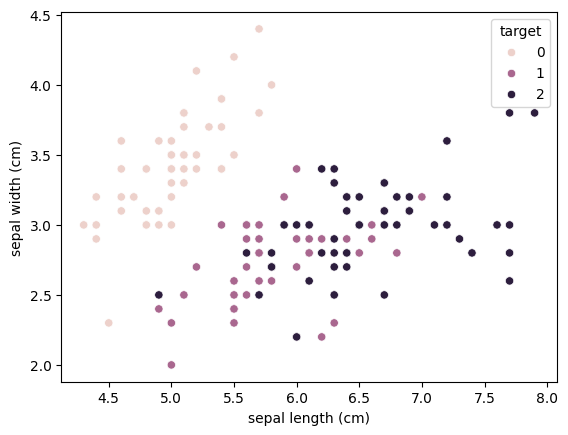

In [ ]:
sns.scatterplot(data=iris_df,x=iris_df.columns[0],y=iris_df.columns[1],hue='target')
plt.show()

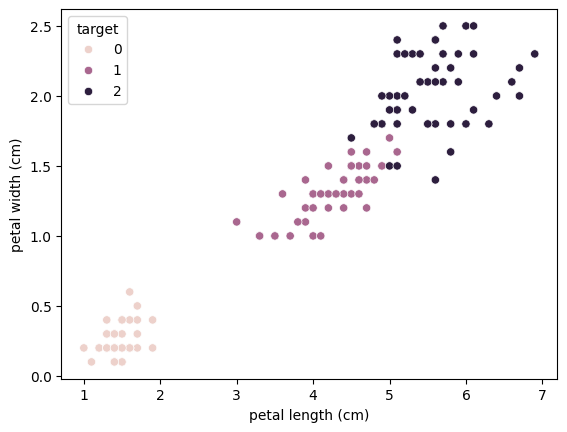

In [ ]:
sns.scatterplot(data=iris_df,x=iris_df.columns[2],y=iris_df.columns[3],hue='target')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(criterion='entropy',max_depth=2)
dt.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2)

In [ ]:
from sklearn.metrics import accuracy_score
y_pred=dt.predict(x_test)
accuracy_score(y_test,y_pred)

0.9666666666666667

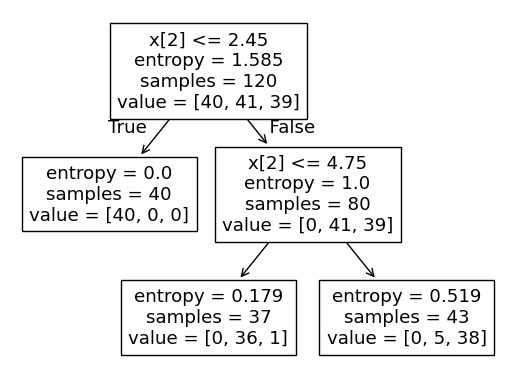

In [ ]:
import sklearn.tree as tree
tree.plot_tree(dt)
plt.show()

In [ ]:
dt.get_depth()

2

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100)
rf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=1000)

In [ ]:
rf.score(x_test,y_test)

1.0

In [ ]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.metrics import accuracy_score


In [ ]:
#!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.0 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

In [ ]:
ada_boost = AdaBoostClassifier(n_estimators=100, learning_rate=0.1)
ada_boost.fit(x_train, y_train)

AdaBoostClassifier(learning_rate=0.1, n_estimators=100)

In [ ]:
ada_boost.score(x_test,y_test)

1.0

In [ ]:
#import XGBClassifier
import xgboost as xgb

In [ ]:
xgb_boost = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1)
xgb_boost.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_boost.score(x_test,y_test)

1.0

###SVM

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
data = pd.read_csv('diabetes.csv')

In [ ]:
data.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
558,11,103,68,40,0,46.2,0.126,42,0
568,4,154,72,29,126,31.3,0.338,37,0
762,9,89,62,0,0,22.5,0.142,33,0
164,0,131,88,0,0,31.6,0.743,32,1
165,6,104,74,18,156,29.9,0.722,41,1
26,7,147,76,0,0,39.4,0.257,43,1
735,4,95,60,32,0,35.4,0.284,28,0
586,8,143,66,0,0,34.9,0.129,41,1
655,2,155,52,27,540,38.7,0.240,25,1
691,13,158,114,0,0,42.3,0.257,44,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
data.describe(include='all')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
data['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
data.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [ ]:
x=data.drop('Outcome',axis=1)
y=data['Outcome']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
svc=SVC()
svc.fit(x_train,y_train)

SVC()

In [ ]:
y_pred=svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.7207792207792207

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {'kernel':['linear','rbf'],'C':[1,10],'gamma':[1,0.1,0.01,0.001]}
grid=GridSearchCV(SVC(),param_grid,refit=True,verbose=3)
grid.fit(x_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END .......C=1, gamma=1, kernel=linear;, score=0.764 total time=   3.7s
[CV 2/5] END .......C=1, gamma=1, kernel=linear;, score=0.789 total time=  10.5s
[CV 3/5] END .......C=1, gamma=1, kernel=linear;, score=0.756 total time=   7.6s
[CV 4/5] END .......C=1, gamma=1, kernel=linear;, score=0.772 total time=   3.7s
[CV 5/5] END .......C=1, gamma=1, kernel=linear;, score=0.803 total time=   1.3s
[CV 1/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.650 total time=   0.0s
[CV 2/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.650 total time=   0.0s
[CV 3/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.650 total time=   0.0s
[CV 4/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.650 total time=   0.0s
[CV 5/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.656 total time=   0.0s
[CV 1/5] END .....C=1, gamma=0.1, kernel=linear;, score=0.764 total time=   1.4s
[CV 2/5] END .....C=1, gamma=0.1, kernel=linear;

GridSearchCV(estimator=SVC(),
             param_grid={'C': [1, 10], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['linear', 'rbf']},
             verbose=3)

###Deep Learning

In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers , Model
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import load_iris

In [ ]:
df=load_iris()

In [ ]:
x=pd.DataFrame(df['data'],columns=df['feature_names'])
y=pd.DataFrame(df['target'],columns=['target'])

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model=tf.keras.Sequential([
    layers.InputLayer(shape=(4,)),
    layers.Dense(64,activation='relu'),
    layers.Dense(32,activation='relu'),
    layers.Dense(16,activation='relu'),
    layers.Dense(8,activation='relu'),
    layers.Dense(3,activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
output=model.fit(x_train,y_train,epochs=100,validation_data=(x_test,y_test))

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.2852 - loss: 1.3325 - val_accuracy: 0.3667 - val_loss: 1.0985
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3185 - loss: 1.1270 - val_accuracy: 0.3667 - val_loss: 1.0468
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3290 - loss: 1.0682 - val_accuracy: 0.3667 - val_loss: 1.0293
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4565 - loss: 1.0357 - val_accuracy: 0.7000 - val_loss: 1.0075
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6550 - loss: 1.0215 - val_accuracy: 0.7000 - val_loss: 0.9887
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6790 - loss: 0.9905 - val_accuracy: 0.7000 - val_loss: 0.9632
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6581 - loss: 0.9746 - val_accuracy: 0.7000 - val_loss: 0.9482
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6488 - loss: 0.9520 - val_accuracy: 0.7000 - val_loss: 0

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,275 (36.23 KB)

 Trainable params: 3,091 (12.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,184 (24.16 KB)

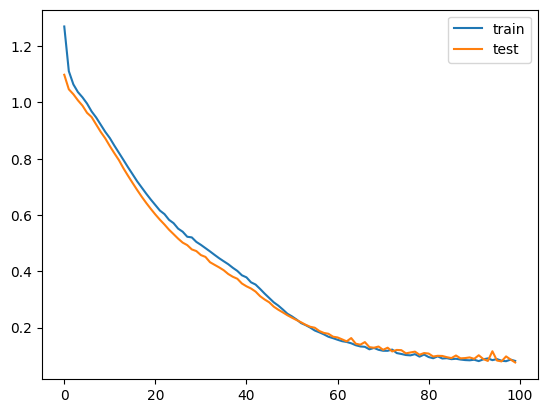

In [ ]:
plt.plot(output.history['loss'])
plt.plot(output.history['val_loss'])
plt.legend(['train','test'])
plt.show()

###Clustering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans , DBSCAN
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv('/content/synthetic_clusters.csv')
df.head()

,X1,X2,label
0,4.787619,13.631829,2
1,6.260971,2.148492,1
2,5.888269,2.357000,1
3,2.216837,2.922822,0
4,2.443080,2.102821,0


In [ ]:
x=df[['X1','X2']].values

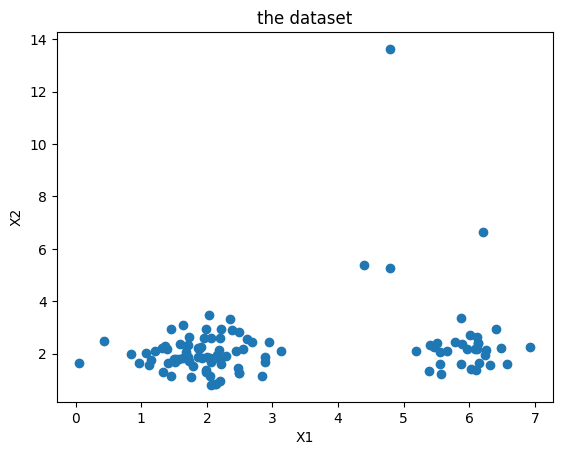

In [ ]:
plt.scatter(x[:,0],x[:,1])
plt.title('the dataset')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

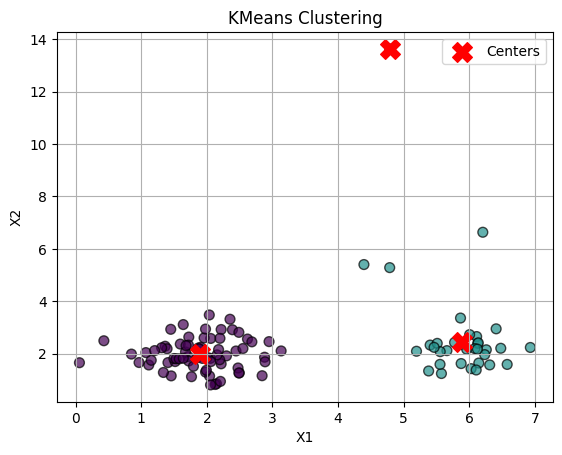

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

k_means = KMeans(n_clusters=3, random_state=42)
labels = k_means.fit_predict(x)

plt.scatter(x[:, 0], x[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7, edgecolor='k')

plt.scatter(k_means.cluster_centers_[:, 0],
            k_means.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centers')

plt.title('KMeans Clustering')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
dbscan=DBSCAN(eps=.8,min_samples=5)
labels_dbscan=dbscan.fit_predict(x)

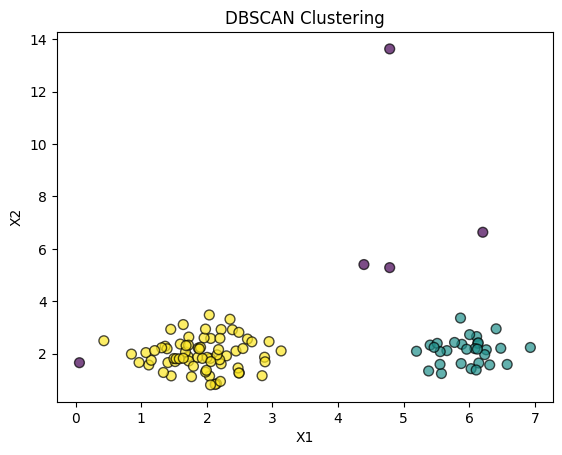

In [ ]:
#visualizing dbscan
plt.scatter(x[:,0],x[:,1],c=labels_dbscan,cmap='viridis',s=50,alpha=0.7,edgecolor='k')
plt.title('DBSCAN Clustering')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()